In [1]:
import glob
import json
import random
import re
from copy import deepcopy as dc
from os.path import join as opj

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from scipy.stats import spearmanr

from cloth_fmri.config.config import CONFIG
from cloth_fmri.utils.stats import (
    bootstrap_ci,
    bootstrap_cor,
    calc_p,
)
from cloth_fmri.utils.plot import (
    plot_scene_bar_with_points,
    plot_bootstrap_violin,
)
from cloth_fmri.utils.svm import (
    get_cnn_distance,
    get_woven_distance,
    get_videomae_distance,
    get_vivit_distance,
    get_vjepa2_distance,
)


random.seed(9)

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/nilearn/__init__.py:67: FutureWarning: Python 3.7 support is deprecated and will be removed in release 0.12 of Nilearn. Consider switching to Python 3.9 or 3.10.
  _python_deprecation_warnings()


In [2]:
model_order = [
    "Woven",
    "V-JEPA2",
    "VideoMAE",
    "ViViT",
    "CNN",
]

video_models = [
    "V-JEPA2",
    "VideoMAE",
    "ViViT",
]



# These directories are used only to find available layer indices.
video_model_layer_dirs = {
    "V-JEPA2": "vjepa2_hf_ridge_mean_1.0_ntrain=7075",
    "VideoMAE": "videomae_ridge_mean_1.0_ntrain=7075",
    "ViViT": "vivit_ridge_cls_1.0_ntrain=7075",
}


def get_available_layers(model_name):
    pred_dir = opj(
        CONFIG["output_root"],
        "analysis",
        "model_predictions_all_layers",
        video_model_layer_dirs[model_name],
    )

    pred_files = glob.glob(
        opj(
            pred_dir,
            "pred_dict_layer_index=*_layer_number=*.npy",
        )
    )

    layers = []

    for pred_file in pred_files:
        match = re.search(
            r"layer_index=(\d+)",
            pred_file,
        )

        if match is not None:
            layers.append(
                int(match.group(1))
            )

    layers = sorted(
        set(layers)
    )

    if len(layers) == 0:
        raise FileNotFoundError(
            f"No layer prediction files found for {model_name}:\n"
            f"{pred_dir}"
        )

    return layers


def get_model_distance_for_layer(
    current_model,
    layer,
):
    """
    Keep the original five-model dictionary.

    Only the currently analyzed video model receives layer=layer.
    All other models use their original/default predictions.
    """

    if current_model == "V-JEPA2":
        model_distance = {
            "Woven": get_woven_distance(
                verbose=False
            ),
            "V-JEPA2": get_vjepa2_distance(
                verbose=False,
                layer=layer,
            ),
            "VideoMAE": get_videomae_distance(
                verbose=False,
            ),
            "ViViT": get_vivit_distance(
                verbose=False
            ),
            "CNN": get_cnn_distance(
                verbose=False
            ),
        }

    elif current_model == "VideoMAE":
        model_distance = {
            "Woven": get_woven_distance(
                verbose=False
            ),
            "V-JEPA2": get_vjepa2_distance(
                verbose=False
            ),
            "VideoMAE": get_videomae_distance(
                verbose=False,
                layer=layer,
            ),
            "ViViT": get_vivit_distance(
                verbose=False
            ),
            "CNN": get_cnn_distance(
                verbose=False
            ),
        }

    elif current_model == "ViViT":
        model_distance = {
            "Woven": get_woven_distance(
                verbose=False
            ),
            "V-JEPA2": get_vjepa2_distance(
                verbose=False
            ),
            "VideoMAE": get_videomae_distance(
                verbose=False
            ),
            "ViViT": get_vivit_distance(
                verbose=False,
                layer=layer,
            ),
            "CNN": get_cnn_distance(
                verbose=False
            ),
        }

    else:
        raise ValueError(
            f"Unsupported current model: {current_model}"
        )

    return model_distance


rois = [
    "tower",
    "v1",
]

In [3]:
# ============================================================
# Find the best neural SVM result for each ROI
# Original logic is unchanged.
# ============================================================
human_acc = {}
best_svm = {}

for roi in rois:
    best_split_half_r_all_subs = -1
    best_split_half_p = None
    best_all_acc_means = None
    best_bootstrap_correlation = None
    best_params = None

    for leave_scene in ["1", "2"]:
        for C in ["0.1", "1.0", "10.0", "100.0"]:
            for smooth in ["0", "1", "2"]:
                input_dir = opj(
                    CONFIG["output_root"], "analysis", "fig3",
                    f"leave-{leave_scene}-run-out",
                    f"C={C}", f"smooth={smooth}", roi)

                files = glob.glob(opj(input_dir, "*.json"), recursive=False)

                if len(files) == 0:
                    continue

                all_data = []

                for file_path in files:
                    with open(file_path, "r") as f_obj:
                        data = json.load(f_obj)["tower_acc_all_tmps"]

                    for key_sub in data:
                        for key_scene in data[key_sub]:
                            data[key_sub][key_scene] = np.mean(
                                data[key_sub][key_scene]
                            )

                    scene_order = CONFIG["scenes"]
                    subjects = sorted(
                        data.keys()
                    )

                    array_2d = np.array([
                        [
                            data[subj][scene]
                            for scene in scene_order
                        ]
                        for subj in subjects
                    ])

                    all_data.append(
                        array_2d
                    )

                all_acc_means = np.mean(
                    np.array(all_data),
                    axis=0,
                )

                (
                    split_half_r_all_subs,
                    p,
                    bootstrap_correlations,
                ) = bootstrap_cor(
                    all_acc_means,
                    seed=99,
                )

                if (
                    split_half_r_all_subs
                    > best_split_half_r_all_subs
                ):
                    best_split_half_r_all_subs = (
                        split_half_r_all_subs
                    )

                    best_split_half_p = p

                    best_bootstrap_correlation = dc(
                        bootstrap_correlations
                    )

                    best_all_acc_means = dc(
                        all_acc_means
                    )

                    best_params = {
                        "leave_scene": leave_scene,
                        "C": C,
                        "smooth": smooth,
                        "input_dir": input_dir,
                    }

    if best_all_acc_means is None:
        raise RuntimeError(
            f"No valid neural SVM results found for ROI={roi}"
        )

    human_acc[roi] = dc(
        best_all_acc_means
    )

    best_svm[roi] = {
        "split_half_r": best_split_half_r_all_subs,
        "split_half_p": best_split_half_p,
        "bootstrap_correlation": dc(
            best_bootstrap_correlation
        ),
        "acc": dc(
            best_all_acc_means
        ),
        "params": dc(
            best_params
        ),
    }

    print("=" * 80)
    print(f"ROI: {roi}")
    print(
        "Best parameters:",
        best_params,
    )
    print(
        f"Split-half reliability: "
        f"r={best_split_half_r_all_subs:.3f}, "
        f"p={best_split_half_p}"
    )

ROI: tower
Best parameters: {'leave_scene': '2', 'C': '10.0', 'smooth': '2', 'input_dir': '/gpfs/milgram/pi/yildirim/wb338/github/fmri/submit_new_codes_after_nc-r1/new/outputs/analysis/fig3/leave-2-run-out/C=10.0/smooth=2/tower'}
Split-half reliability: r=0.724, p=0.0474
ROI: v1
Best parameters: {'leave_scene': '1', 'C': '1.0', 'smooth': '2', 'input_dir': '/gpfs/milgram/pi/yildirim/wb338/github/fmri/submit_new_codes_after_nc-r1/new/outputs/analysis/fig3/leave-1-run-out/C=1.0/smooth=2/v1'}
Split-half reliability: r=0.745, p=0.0336


In [4]:
###### This is bootstrapped interaction

# # ============================================================
# # Neural SVM accuracy arrays
# # ============================================================

roi_acc = {
    "Physics ROI": human_acc["tower"],
    "V1": human_acc["v1"],
}

roi_order = [
    "Physics ROI",
    "V1",
]


# # ============================================================
# # Loop over every video model and every layer
# # ============================================================

# all_layer_results = []

# # Optional:
# # retain all bootstrap distributions in memory.
# all_layer_model_cor = {}

# for current_model in video_models:
#     layers = get_available_layers(current_model)
#     all_layer_model_cor[current_model] = {}

#     print("\n")
#     print("#" * 100)
#     print(f"CURRENT MODEL: {current_model}")
#     print(f"AVAILABLE LAYERS: {layers}")
#     print("#" * 100)

#     for layer in layers:

#         print("\n")
#         print("=" * 90)
#         print(
#             f"{current_model} | "
#             f"layer index={layer} | "
#             f"layer number={layer + 1}"
#         )
#         print("=" * 90)

#         # ----------------------------------------------------
#         # Original five-model dictionary.
#         #
#         # Only current_model receives layer=layer.
#         # ----------------------------------------------------

#         model_distance = get_model_distance_for_layer(current_model=current_model, layer=layer)

#         # ----------------------------------------------------
#         # Original model mean calculation
#         # ----------------------------------------------------

#         model_mean = {}

#         for model_name in model_order:
#             model_mean[model_name] = [np.mean(model_distance[model_name][scene][:62]) for scene in CONFIG["scenes"]]

#         # ----------------------------------------------------
#         # Correlation of current layer with Woven and CNN/DNN
#         # ----------------------------------------------------
#         woven_r, woven_p = spearmanr(model_mean[current_model], model_mean["Woven"])
#         dnn_r, dnn_p = spearmanr(model_mean[current_model], model_mean["CNN"])

#         print(
#             f"Correlation with Woven: "
#             f"r={woven_r:.3f}, "
#             f"p={woven_p:.3f}"
#         )

#         print(
#             f"Correlation with CNN/DNN: "
#             f"r={dnn_r:.3f}, "
#             f"p={dnn_p:.3f}"
#         )


#         current_result = {
#             "model": current_model,
#             "layer_index": layer,
#             "layer_number": layer + 1,
#             "woven_spearman": woven_r,
#             "woven_p": woven_p,
#             "dnn_spearman": dnn_r,
#             "dnn_p": dnn_p,
#         }

#         all_layer_model_cor[current_model][layer] = {}

#         # ----------------------------------------------------
#         # Original neural bootstrap correlation logic
#         # ----------------------------------------------------

#         for roi_name in roi_order:
#             acc = roi_acc[roi_name]
#             nsub = acc.shape[0]
#             all_layer_model_cor[current_model][layer][roi_name] = {}

#             for model_name in model_order:
#                 cur_cor = []
#                 for curboot in range(10000):
#                     human_boot_indices = np.random.choice(nsub, nsub, replace=True)
#                     human_boot = acc[human_boot_indices, :]
#                     human_boot_acc_across_scenes = np.mean(human_boot, axis=0)
#                     cur_r, _ = spearmanr(model_mean[model_name], human_boot_acc_across_scenes)
#                     cur_cor.append(cur_r)

#                 all_layer_model_cor[current_model][layer][roi_name][model_name] = dc(cur_cor)

#             # We print and save the current layer model.
#             current_cor = all_layer_model_cor[current_model][layer][roi_name][current_model]
#             current_cor = np.asarray(current_cor, dtype=float)
#             current_mean_r = np.nanmean(current_cor)
#             current_ci_low = np.nanpercentile(current_cor, 2.5)
#             current_ci_high = np.nanpercentile(current_cor, 97.5)
#             current_p = calc_p(current_cor)

#             # Point estimate using mean neural accuracy
#             # across subjects.
#             neural_mean_across_scenes = np.mean(acc, axis=0)
#             current_point_r, current_point_p = spearmanr(model_mean[current_model], neural_mean_across_scenes)

#             if roi_name == "Physics ROI":
#                 roi_key = "physics"
#             else:
#                 roi_key = "v1"

#             current_result[f"{roi_key}_neural_spearman"] = current_point_r
#             current_result[f"{roi_key}_neural_p"] = current_point_p
#             current_result[f"{roi_key}_bootstrap_mean_spearman"] = current_mean_r
#             current_result[f"{roi_key}_bootstrap_ci_low"] = current_ci_low
#             current_result[f"{roi_key}_bootstrap_ci_high"] = current_ci_high
#             current_result[f"{roi_key}_bootstrap_p"] = current_p

#             print(
#                 f"Correlation with {roi_name}: "
#                 f"r={current_point_r:.3f}, "
#                 f"bootstrap mean={current_mean_r:.3f}, "
#                 f"CI=({current_ci_low:.3f}, "
#                 f"{current_ci_high:.3f}), "
#                 f"p={current_p:.3f}"
#             )

            
            
#         # ============================================================
#         # Model x ROI interaction
#         # ============================================================

#         physics_layer = np.asarray(all_layer_model_cor[current_model][layer]["Physics ROI"][current_model], dtype=float)
#         physics_dnn = np.asarray(all_layer_model_cor[current_model][layer]["Physics ROI"]["CNN"], dtype=float)
#         v1_layer = np.asarray(all_layer_model_cor[current_model][layer]["V1"][current_model], dtype=float)
#         v1_dnn = np.asarray(all_layer_model_cor[current_model][layer]["V1"]["CNN"], dtype=float)

        
#         interaction_bootstrap = (physics_layer-physics_dnn-v1_layer+v1_dnn)
#         interaction_effect = np.nanmean(interaction_bootstrap)
#         interaction_p = calc_p(interaction_bootstrap)
#         current_result["interaction_effect"] = interaction_effect
#         current_result["interaction_p"] = interaction_p

        
#         all_layer_results.append(current_result)

In [5]:
######## This is parametric test for interaction


# ============================================================
# Loop over every video model and every layer
# ============================================================

all_layer_results = []

for current_model in video_models:

    layers = get_available_layers(current_model)

    print("\n")
    print("#" * 100)
    print(f"CURRENT MODEL: {current_model}")
    print(f"AVAILABLE LAYERS: {layers}")
    print("#" * 100)


    for layer in layers:

        print("\n")
        print("=" * 90)
        print(
            f"{current_model} | layer index={layer} | layer number={layer+1}"
        )
        print("=" * 90)


        model_distance = get_model_distance_for_layer(
            current_model=current_model,
            layer=layer,
        )


        model_mean = {}

        for model_name in model_order:
            model_mean[model_name] = [
                np.mean(
                    model_distance[model_name][scene][:62]
                )
                for scene in CONFIG["scenes"]
            ]


        woven_r, woven_p = spearmanr(
            model_mean[current_model],
            model_mean["Woven"],
        )

        dnn_r, dnn_p = spearmanr(
            model_mean[current_model],
            model_mean["CNN"],
        )


        print(
            f"Correlation with Woven: r={woven_r:.3f}, p={woven_p:.3f}"
        )

        print(
            f"Correlation with CNN/DNN: r={dnn_r:.3f}, p={dnn_p:.3f}"
        )


        current_result = {
            "model": current_model,
            "layer_index": layer,
            "layer_number": layer + 1,
            "woven_spearman": woven_r,
            "woven_p": woven_p,
            "dnn_spearman": dnn_r,
            "dnn_p": dnn_p,
        }


        # ====================================================
        # Neural bootstrap correlations
        # ====================================================

        for roi_name in roi_order:

            acc = roi_acc[roi_name]
            nsub = acc.shape[0]


            cur_cor = []

            for model_name in model_order:

                cur_cor = []

                for curboot in range(10000):

                    human_boot_indices = np.random.choice(
                        nsub,
                        nsub,
                        replace=True,
                    )

                    human_boot = acc[human_boot_indices, :]

                    human_boot_acc = np.mean(
                        human_boot,
                        axis=0,
                    )

                    cur_r, _ = spearmanr(
                        model_mean[model_name],
                        human_boot_acc,
                    )

                    cur_cor.append(cur_r)


                if model_name == current_model:

                    current_cor = np.asarray(
                        cur_cor,
                        dtype=float,
                    )

                    current_mean_r = np.nanmean(
                        current_cor
                    )

                    current_ci_low = np.nanpercentile(
                        current_cor,
                        2.5,
                    )

                    current_ci_high = np.nanpercentile(
                        current_cor,
                        97.5,
                    )

                    current_p = calc_p(
                        current_cor
                    )


            neural_mean = np.mean(
                acc,
                axis=0,
            )

            point_r, point_p = spearmanr(
                model_mean[current_model],
                neural_mean,
            )


            roi_key = (
                "physics"
                if roi_name == "Physics ROI"
                else "v1"
            )


            current_result[f"{roi_key}_neural_spearman"] = point_r
            current_result[f"{roi_key}_neural_p"] = point_p
            current_result[f"{roi_key}_bootstrap_mean_spearman"] = current_mean_r
            current_result[f"{roi_key}_bootstrap_ci_low"] = current_ci_low
            current_result[f"{roi_key}_bootstrap_ci_high"] = current_ci_high
            current_result[f"{roi_key}_bootstrap_p"] = current_p



        # ====================================================
        # Parametric Model x ROI interaction
        # ====================================================

        interaction_rows = []


        for sub in range(
            roi_acc["Physics ROI"].shape[0]
        ):

            physics_acc = roi_acc["Physics ROI"][sub]
            v1_acc = roi_acc["V1"][sub]


            interaction_rows += [

                {
                    "subject": sub,
                    "Model": "Layer",
                    "ROI": "Physics",
                    "r": spearmanr(
                        model_mean[current_model],
                        physics_acc,
                    )[0],
                },

                {
                    "subject": sub,
                    "Model": "Layer",
                    "ROI": "V1",
                    "r": spearmanr(
                        model_mean[current_model],
                        v1_acc,
                    )[0],
                },

                {
                    "subject": sub,
                    "Model": "DNN",
                    "ROI": "Physics",
                    "r": spearmanr(
                        model_mean["CNN"],
                        physics_acc,
                    )[0],
                },

                {
                    "subject": sub,
                    "Model": "DNN",
                    "ROI": "V1",
                    "r": spearmanr(
                        model_mean["CNN"],
                        v1_acc,
                    )[0],
                },

            ]


        interaction_df = pd.DataFrame(
            interaction_rows
        )


        interaction_df["z"] = np.arctanh(
            interaction_df["r"]
        )


        # ----------------------------
        # Repeated-measures ANOVA
        # ----------------------------

        interaction_anova = pg.rm_anova(
            data=interaction_df,
            dv="z",
            within=[
                "Model",
                "ROI",
            ],
            subject="subject",
            detailed=True,
        )


        current_result["interaction_F"] = interaction_anova.loc[
            interaction_anova["Source"] == "Model * ROI",
            "F",
        ].values[0]


        current_result["interaction_p"] = interaction_anova.loc[
            interaction_anova["Source"] == "Model * ROI",
            "p-unc",
        ].values[0]


        # ----------------------------
        # Signed interaction effect
        # ----------------------------

        current_result["interaction_effect"] = (

            interaction_df.query(
                "Model=='Layer' and ROI=='Physics'"
            )["z"].mean()

            -

            interaction_df.query(
                "Model=='DNN' and ROI=='Physics'"
            )["z"].mean()

            -

            (
                interaction_df.query(
                    "Model=='Layer' and ROI=='V1'"
                )["z"].mean()

                -

                interaction_df.query(
                    "Model=='DNN' and ROI=='V1'"
                )["z"].mean()
            )
        )


        print(
            f"Interaction effect={current_result['interaction_effect']:.3f}, "
            f"F={current_result['interaction_F']:.3f}, "
            f"p={current_result['interaction_p']:.4f}"
        )


        all_layer_results.append(
            current_result
        )





####################################################################################################
CURRENT MODEL: V-JEPA2
AVAILABLE LAYERS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
####################################################################################################


V-JEPA2 | layer index=0 | layer number=1
Correlation with Woven: r=0.000, p=1.000
Correlation with CNN/DNN: r=1.000, p=0.000


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:747: RuntimeWarning: invalid value encountered in double_scalars
  f_a = ms_a / ms_as
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:748: RuntimeWarning: invalid value encountered in double_scalars
  f_b = ms_b / ms_bs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:749: RuntimeWarning: invalid value encountered in double_scalars
  f_ab = ms_ab / ms_abs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:764: RuntimeWarning: invalid value encountered in double_scalars
  ef_a = s

Interaction effect=nan, F=nan, p=nan


V-JEPA2 | layer index=1 | layer number=2
Correlation with Woven: r=-0.200, p=0.800
Correlation with CNN/DNN: r=0.400, p=0.600


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:747: RuntimeWarning: invalid value encountered in double_scalars
  f_a = ms_a / ms_as
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:748: RuntimeWarning: invalid value encountered in double_scalars
  f_b = ms_b / ms_bs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:749: RuntimeWarning: invalid value encountered in double_scalars
  f_ab = ms_ab / ms_abs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:764: RuntimeWarning: invalid value encountered in double_scalars
  ef_a = s

Interaction effect=nan, F=nan, p=nan


V-JEPA2 | layer index=2 | layer number=3
Correlation with Woven: r=0.000, p=1.000
Correlation with CNN/DNN: r=1.000, p=0.000


...

/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:747: RuntimeWarning: invalid value encountered in double_scalars
  f_a = ms_a / ms_as
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:748: RuntimeWarning: invalid value encountered in double_scalars
  f_b = ms_b / ms_bs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:749: RuntimeWarning: invalid value encountered in double_scalars
  f_ab = ms_ab / ms_abs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:764: RuntimeWarning: invalid value encountered in double_scalars
  ef_a = s

Interaction effect=nan, F=nan, p=nan


ViViT | layer index=10 | layer number=11
Correlation with Woven: r=-0.200, p=0.800
Correlation with CNN/DNN: r=0.400, p=0.600


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:747: RuntimeWarning: invalid value encountered in double_scalars
  f_a = ms_a / ms_as
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:748: RuntimeWarning: invalid value encountered in double_scalars
  f_b = ms_b / ms_bs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:749: RuntimeWarning: invalid value encountered in double_scalars
  f_ab = ms_ab / ms_abs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:764: RuntimeWarning: invalid value encountered in double_scalars
  ef_a = s

Interaction effect=nan, F=nan, p=nan


ViViT | layer index=11 | layer number=12
Correlation with Woven: r=0.000, p=1.000
Correlation with CNN/DNN: r=1.000, p=0.000
Interaction effect=nan, F=nan, p=nan


/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in arctanh
  result = getattr(ufunc, method)(*inputs, **kwargs)
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:747: RuntimeWarning: invalid value encountered in double_scalars
  f_a = ms_a / ms_as
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:748: RuntimeWarning: invalid value encountered in double_scalars
  f_b = ms_b / ms_bs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:749: RuntimeWarning: invalid value encountered in double_scalars
  f_ab = ms_ab / ms_abs
/gpfs/milgram/project/yildirim/wb338/conda_envs/mybrainiak/lib/python3.7/site-packages/pingouin/parametric.py:764: RuntimeWarning: invalid value encountered in double_scalars
  ef_a = s

In [6]:
# ============================================================
# Combine and save results
# ============================================================

all_layer_results_df = pd.DataFrame(all_layer_results)
all_layer_results_df = (all_layer_results_df.sort_values(["model", "layer_index"]).reset_index(drop=True))

output_csv = opj(
    CONFIG["output_root"],
    "analysis",
    "model_predictions_all_layers",
    "video_models_all_layers_svm_correlations.csv")

all_layer_results_df.to_csv(output_csv, index=False)

print("\n")
print("Saved:")
print(output_csv)


# ============================================================
# Excel-friendly summary
# ============================================================

summary_columns = [
    "model",
    "layer_index",
    "layer_number",
    "physics_neural_spearman",
    "physics_bootstrap_mean_spearman",
    "physics_bootstrap_ci_low",
    "physics_bootstrap_ci_high",
    "physics_bootstrap_p",
    "v1_neural_spearman",
    "v1_bootstrap_mean_spearman",
    "v1_bootstrap_ci_low",
    "v1_bootstrap_ci_high",
    "v1_bootstrap_p",
    "woven_spearman",
    "woven_p",
    "dnn_spearman",
    "dnn_p",
    "interaction_effect",
]

print("\n")
print("Excel-friendly summary:")

print(all_layer_results_df[summary_columns].to_csv(index=False, sep="\t", na_rep="", float_format="%.3f"))



Saved:
/gpfs/milgram/pi/yildirim/wb338/github/fmri/submit_new_codes_after_nc-r1/new/outputs/analysis/model_predictions_all_layers/video_models_all_layers_svm_correlations.csv


Excel-friendly summary:
model	layer_index	layer_number	physics_neural_spearman	physics_bootstrap_mean_spearman	physics_bootstrap_ci_low	physics_bootstrap_ci_high	physics_bootstrap_p	v1_neural_spearman	v1_bootstrap_mean_spearman	v1_bootstrap_ci_low	v1_bootstrap_ci_high	v1_bootstrap_p	woven_spearman	woven_p	dnn_spearman	dnn_p	interaction_effect
V-JEPA2	0	1	-0.600	-0.556	-1.000	0.400	0.102	1.000	0.821	0.400	1.000	0.009	0.000	1.000	1.000	0.000	
V-JEPA2	1	2	-0.400	-0.364	-0.800	0.000	0.032	0.400	0.453	0.000	1.000	0.030	-0.200	0.800	0.400	0.600	
V-JEPA2	2	3	-0.600	-0.545	-1.000	0.400	0.114	1.000	0.818	0.400	1.000	0.012	0.000	1.000	1.000	0.000	
V-JEPA2	3	4	-0.600	-0.546	-1.000	0.400	0.112	1.000	0.821	0.400	1.000	0.009	0.000	1.000	1.000	0.000	
V-JEPA2	4	5	0.200	0.162	-0.400	0.800	0.441	0.200	-0.017	-0.800	0.400	0.912	

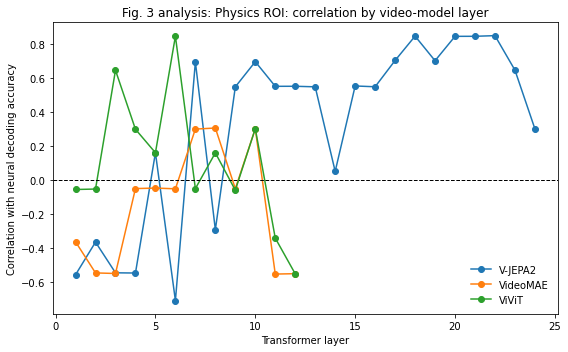

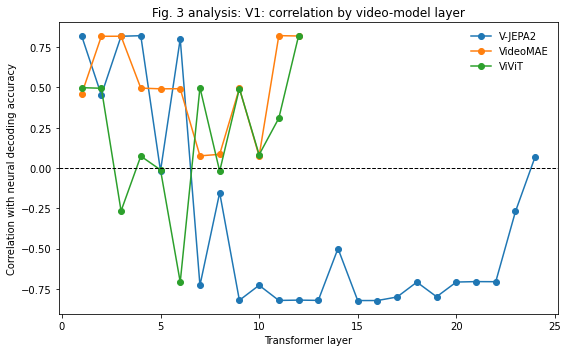

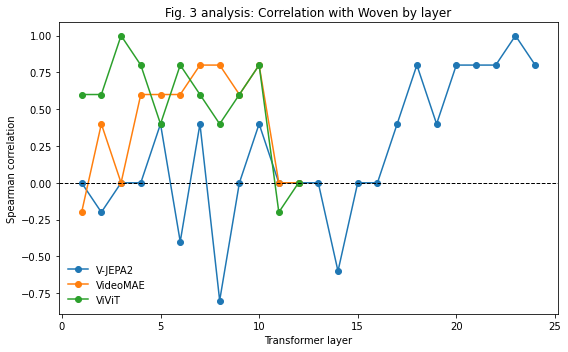

FileNotFoundError: [Errno 2] No such file or directory: 'Fig. 3 analysis: Correlation with CNN/DNN by layer.eps'

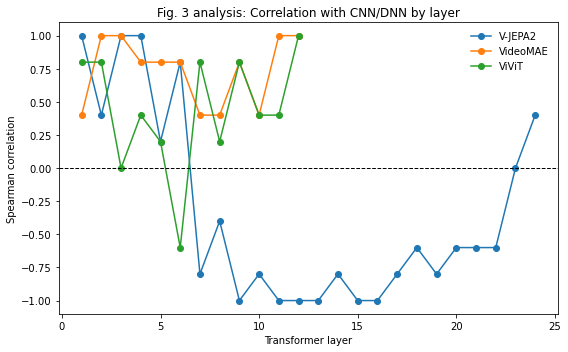

In [9]:
# ============================================================
# Plot neural correlation across layers
# ============================================================

for roi_key, roi_label in [("physics", "Physics ROI"), ("v1", "V1")]:
    plt.figure(figsize=(8, 5))
    for model_name in video_models:
        current_df = (all_layer_results_df.query("model == @model_name").sort_values("layer_number"))
        plt.plot(
            current_df["layer_number"],
            current_df[f"{roi_key}_bootstrap_mean_spearman"],
            marker="o",
            label=model_name,
        )

    plt.axhline(y=0.0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Transformer layer")
    plt.ylabel("Correlation with neural decoding accuracy")
    plt.title(f"Fig. 3 analysis: {roi_label}: correlation by video-model layer")
    plt.legend(frameon=False)
    plt.tight_layout()
    
    plt.savefig(
    f"Fig. 3 analysis: {roi_label}: correlation by video-model layer.eps",
    format="eps",
    bbox_inches="tight"
)
    
    plt.show()

# ============================================================
# Plot correlation with Woven and CNN/DNN across layers
# ============================================================
for correlation_column, reference_name in [("woven_spearman", "Woven"), ("dnn_spearman", "CNN/DNN")]:
    plt.figure(figsize=(8, 5))

    for model_name in video_models:
        current_df = (all_layer_results_df.query("model == @model_name").sort_values("layer_number"))
        plt.plot(current_df["layer_number"], current_df[correlation_column], marker="o", label=model_name)

    plt.axhline(y=0.0, color="black", linestyle="--", linewidth=1)
    plt.xlabel("Transformer layer")
    plt.ylabel("Spearman correlation")
    plt.title(f"Fig. 3 analysis: Correlation with {reference_name} by layer")
    plt.legend(frameon=False)
    plt.tight_layout()
    
    plt.savefig(
        f"Fig. 3 analysis: Correlation with {reference_name} by layer.eps",
        format="eps",
        bbox_inches="tight"
    )

    plt.show()
    
    
#     # ============================================================
#     # Plot Model x ROI interaction term across layers
#     # ============================================================
#     plt.figure(figsize=(8,5))

#     for model_name in video_models:
#         current_df = (all_layer_results_df.query("model == @model_name").sort_values("layer_number"))
#         plt.plot(current_df["layer_number"], current_df["interaction_effect"], marker="o", label=model_name)

#     plt.axhline(0, linestyle="--", linewidth=1)
#     plt.xlabel("Transformer layer")
#     plt.ylabel("Model × ROI interaction effect")
#     plt.title("Physics-like interaction across layers")
#     plt.legend(frameon=False)
#     plt.tight_layout()
#     plt.show()

In [ ]:
# # ============================================================
# # Plot Model x ROI interaction term across layers
# # ============================================================

# plt.figure(figsize=(8, 5))

# for model_name in video_models:

#     current_df = (
#         all_layer_results_df
#         .query("model == @model_name")
#         .sort_values("layer_number")
#     )

#     plt.plot(
#         current_df["layer_number"],
#         current_df["interaction_effect"],
#         marker="o",
#         label=model_name,
#     )

#     # mark significant layers
#     sig_df = current_df[
#         current_df["interaction_p"] < 0.05
#     ]

#     plt.scatter(
#         sig_df["layer_number"],
#         sig_df["interaction_effect"],
#         marker="*",
#         s=120,
#         zorder=5,
#     )


# plt.axhline(
#     0,
#     linestyle="--",
#     linewidth=1,
# )


# plt.xlabel(
#     "Transformer layer"
# )


# plt.ylabel(
#     "Model × ROI interaction effect"
# )


# plt.title(
#     "Physics-like interaction across layers\n"
#     "* p < 0.05"
# )


# plt.legend(
#     frameon=False
# )


# plt.tight_layout()

# plt.show()